#  Smart Food Delivery ETA Prediction System
### End-to-End Machine Learning Project (Colab-ready)

**Business problem:** Predict how long a food delivery will take, given distance, weather,
traffic, order details, and courier info — so customers get an accurate ETA.




## Phase 1 — Business Understanding

**Goal:** Predict `Delivery_Time_min` (or your target column) so the platform can:
- Show customers an accurate ETA
- Flag delivery partners who are overloaded
- Detect which conditions (weather/traffic) cause delays




## Phase 2 — Data Collection




In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

df = pd.read_csv("Food_Delivery_Times.csv")
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
df.head()


Shape: (1000, 9)

Columns: ['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [21]:
# Set these once based on your actual column names
TARGET = "Delivery_Time_min"          # <-- change if different
ID_COLS = ["Order_ID"] if "Order_ID" in df.columns else []

print("Target column:", TARGET)
print("Dtypes:\n", df.dtypes)


Target column: Delivery_Time_min
Dtypes:
 Order_ID                    int64
Distance_km               float64
Weather                    object
Traffic_Level              object
Time_of_Day                object
Vehicle_Type               object
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object


## Phase 3 — Data Cleaning

In [22]:
# Missing values
print("Missing values per column:\n", df.isnull().sum())

# Duplicates
print("\nDuplicate rows:", df.duplicated().sum())
df = df.drop_duplicates()

# Drop ID columns (not predictive)
df = df.drop(columns=ID_COLS, errors="ignore")


Missing values per column:
 Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64

Duplicate rows: 0


In [23]:
# Handle missing values: numeric -> median, categorical -> mode
num_cols = df.select_dtypes(include=np.number).columns.tolist()
if TARGET in num_cols:
    num_cols.remove(TARGET)
cat_cols = df.select_dtypes(include="object").columns.tolist()

for c in num_cols:
    df[c] = df[c].fillna(df[c].median())
for c in cat_cols:
    df[c] = df[c].fillna(df[c].mode()[0])

print("Remaining missing values:", df.isnull().sum().sum())


Remaining missing values: 0


In [24]:
# Outlier check on target and key numeric columns using IQR
def iqr_bounds(series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5*iqr, q3 + 1.5*iqr

for c in [TARGET] + num_cols:
    low, high = iqr_bounds(df[c])
    n_out = ((df[c] < low) | (df[c] > high)).sum()
    print(f"{c}: {n_out} potential outliers (bounds {low:.1f} to {high:.1f})")

# We CAP rather than drop, to avoid losing rows on a small dataset
for c in [TARGET] + num_cols:
    low, high = iqr_bounds(df[c])
    df[c] = df[c].clip(lower=low, upper=high)


Delivery_Time_min: 6 potential outliers (bounds -4.0 to 116.0)
Distance_km: 0 potential outliers (bounds -9.8 to 29.9)
Preparation_Time_min: 0 potential outliers (bounds -7.0 to 41.0)
Courier_Experience_yrs: 0 potential outliers (bounds -5.5 to 14.5)


## Phase 4 — Exploratory Data Analysis (EDA)




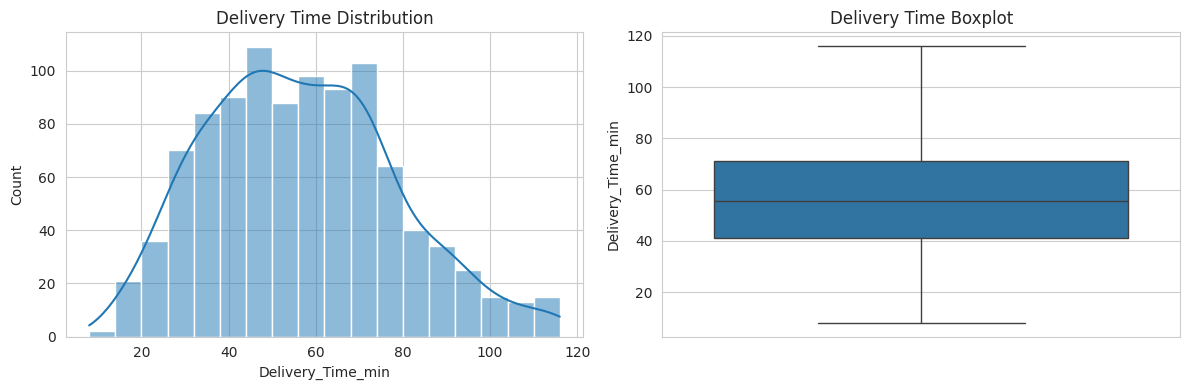

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df[TARGET], kde=True, ax=axes[0]).set_title("Delivery Time Distribution")
sns.boxplot(y=df[TARGET], ax=axes[1]).set_title("Delivery Time Boxplot")
plt.tight_layout(); plt.show()


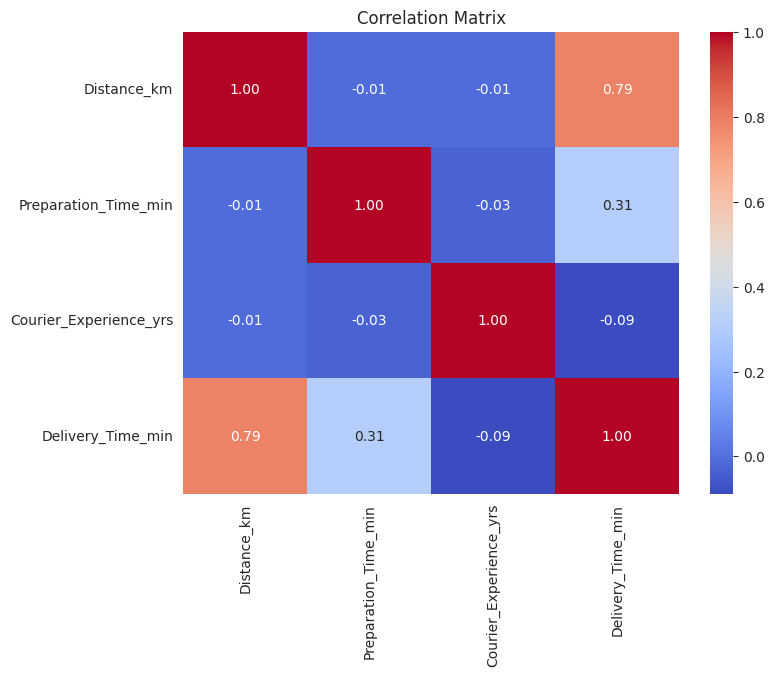

In [26]:
# Correlation heatmap (numeric features)
plt.figure(figsize=(8,6))
sns.heatmap(df[num_cols + [TARGET]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


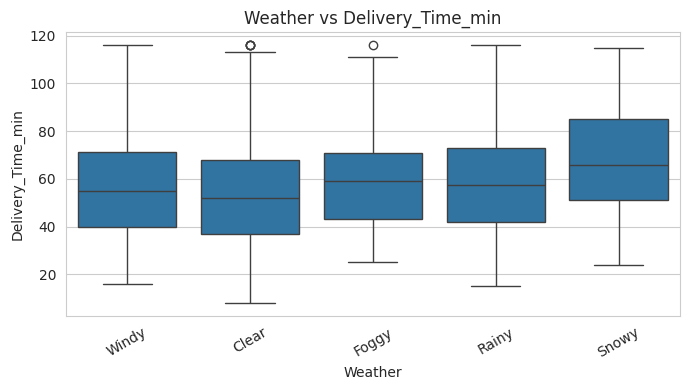

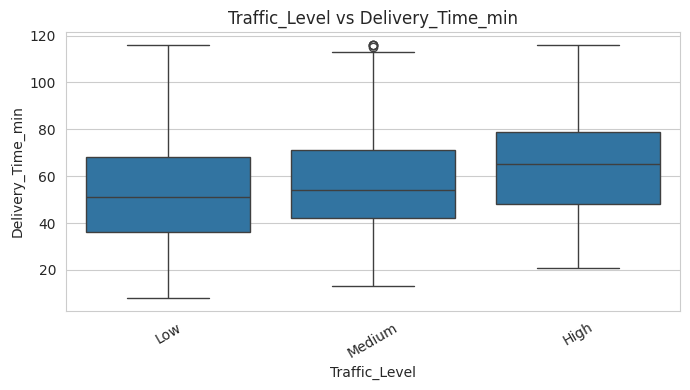

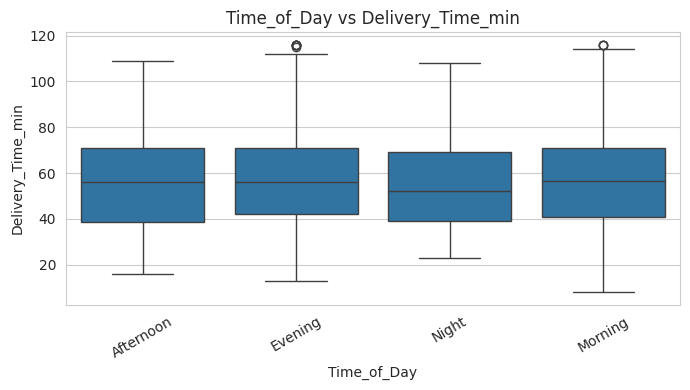

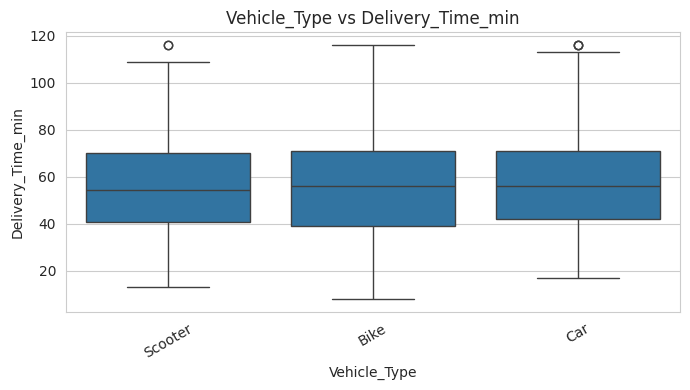

In [27]:
# Categorical features vs delivery time
for c in cat_cols:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df, x=c, y=TARGET)
    plt.title(f"{c} vs {TARGET}")
    plt.xticks(rotation=30)
    plt.tight_layout(); plt.show()


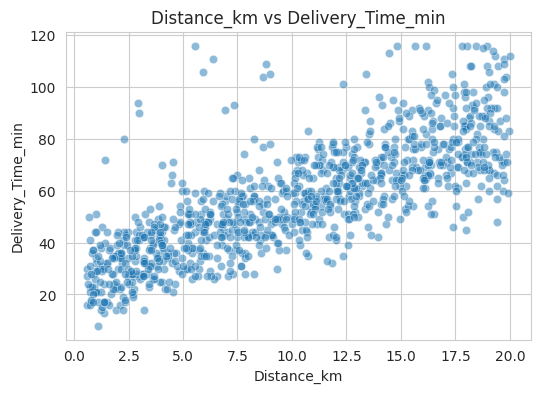

In [28]:
# Distance vs delivery time (key relationship)
dist_col = [c for c in num_cols if "dist" in c.lower()]
if dist_col:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=dist_col[0], y=TARGET, alpha=0.5)
    plt.title(f"{dist_col[0]} vs {TARGET}")
    plt.show()


## Phase 5 — Feature Engineering

In [29]:
df_fe = df.copy()

# Peak-hour / time-of-day flags, if a time-of-day-like column exists
time_col = [c for c in cat_cols if "time" in c.lower() and "prep" not in c.lower()]
if time_col:
    tc = time_col[0]
    df_fe["Is_Peak_Hour"] = df_fe[tc].astype(str).str.contains(
        "Evening|Night|Rush", case=False, na=False).astype(int)

# Weather severity score (ordinal), if a weather column exists
if "Weather" in df_fe.columns:
    weather_map = {"Clear": 0, "Sunny": 0, "Windy": 1, "Cloudy": 1,
                   "Foggy": 2, "Rainy": 3, "Snowy": 3, "Stormy": 4}
    df_fe["Weather_Severity"] = df_fe["Weather"].map(weather_map).fillna(1)

# Traffic severity score, if present
if "Traffic_Level" in df_fe.columns:
    traffic_map = {"Low": 0, "Medium": 1, "High": 2, "Jam": 3}
    df_fe["Traffic_Severity"] = df_fe["Traffic_Level"].map(traffic_map).fillna(1)

# Average delivery speed proxy (distance / prep time), if both exist
prep_col = [c for c in num_cols if "prep" in c.lower()]
if dist_col and prep_col:
    df_fe["Distance_per_PrepMin"] = df_fe[dist_col[0]] / df_fe[prep_col[0]].replace(0, np.nan)
    df_fe["Distance_per_PrepMin"] = df_fe["Distance_per_PrepMin"].fillna(df_fe["Distance_per_PrepMin"].median())

df_fe.head()


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Is_Peak_Hour,Weather_Severity,Traffic_Severity,Distance_per_PrepMin
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,0,1,0,0.660833
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84,1,0,1,0.821000
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59,1,2,0,0.340000
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,0,3,1,1.488000
4,19.03,Clear,Low,Morning,Bike,16,5.0,68,0,0,0,1.189375


## Phase 6 — Preprocessing (Encoding, Split, Scaling)

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# One-hot encode remaining categorical columns
cat_cols_fe = df_fe.select_dtypes(include="object").columns.tolist()
df_encoded = pd.get_dummies(df_fe, columns=cat_cols_fe, drop_first=True)

X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (800, 18)  Test shape: (200, 18)


## Phase 7 — Model Building (Compare Several Models)

In [31]:
!pip install -q xgboost shap


In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42, n_estimators=300, verbosity=0),
}

results = []
for name, model in models.items():
    # Linear model benefits from scaled features; tree models don't need it but it doesn't hurt
    if name == "Linear Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"]).sort_values("RMSE")
results_df


,Model,MAE,RMSE,R2
0,Linear Regression,5.830507,8.665917,0.831017
3,Gradient Boosting,6.486067,9.228680,0.808357
4,XGBoost,7.025336,9.497381,0.797035
2,Random Forest,6.594500,9.510535,0.796472
1,Decision Tree,10.410000,14.901342,0.500352


**Pick the best model** based on lowest RMSE / MAE and highest R². Tree ensembles
(Random Forest, Gradient Boosting, XGBoost) usually win on this kind of tabular data.


## Phase 8 — Hyperparameter Tuning

Tuning the best-performing model from Phase 7 (example uses XGBoost — swap in
whichever model won above).


In [33]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
}

best_model_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_distributions=param_grid,
    n_iter=25,
    scoring="neg_root_mean_squared_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
)

best_model_search.fit(X_train, y_train)
print("Best params:", best_model_search.best_params_)

final_model = best_model_search.best_estimator_


Best params: {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'colsample_bytree': 1.0}


## Phase 9 — Model Evaluation

In [34]:
preds_final = final_model.predict(X_test)

mae = mean_absolute_error(y_test, preds_final)
rmse = np.sqrt(mean_squared_error(y_test, preds_final))
r2 = r2_score(y_test, preds_final)

print(f"Final Tuned Model — MAE: {mae:.2f} min | RMSE: {rmse:.2f} min | R2: {r2:.3f}")


Final Tuned Model — MAE: 6.22 min | RMSE: 8.94 min | R2: 0.820


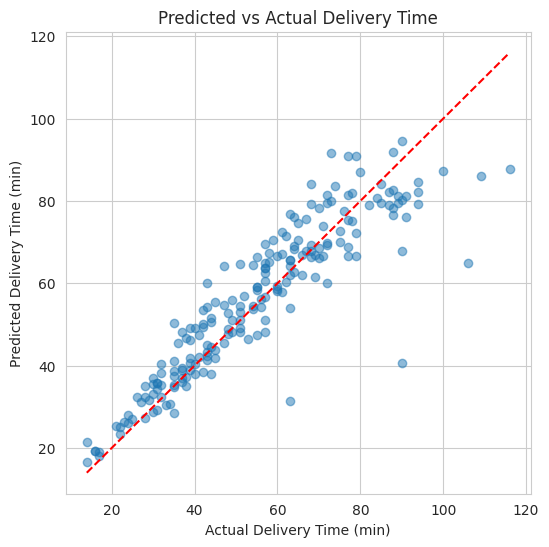

In [35]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, preds_final, alpha=0.5)
lims = [min(y_test.min(), preds_final.min()), max(y_test.max(), preds_final.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("Actual Delivery Time (min)")
plt.ylabel("Predicted Delivery Time (min)")
plt.title("Predicted vs Actual Delivery Time")
plt.show()


## Phase 10 — Explainability (SHAP)

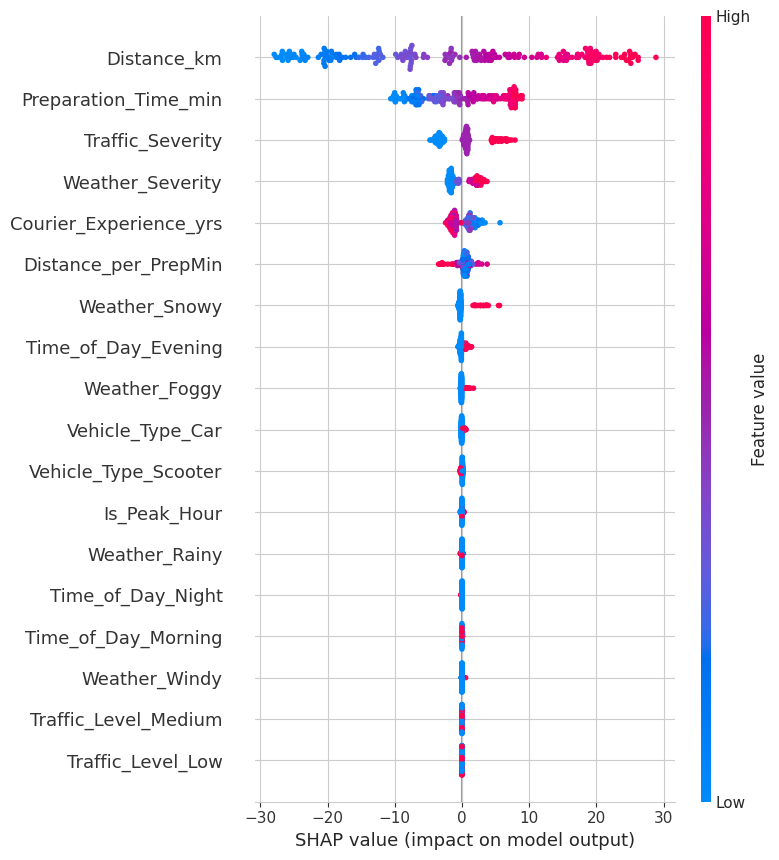

In [36]:
import shap

explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=True)


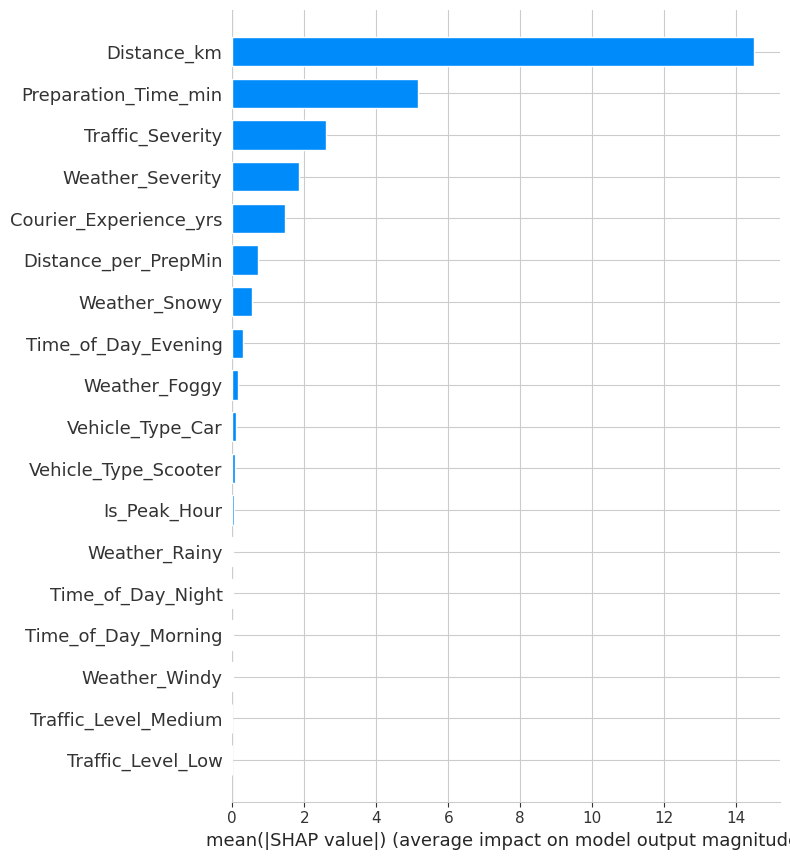

In [37]:
# Bar chart: which feature matters most on average
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)


## Phase 11 — Save the Model (for Deployment)




In [39]:
import joblib

joblib.dump(final_model, "delivery_time_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(list(X.columns), "model_columns.pkl")

from google.colab import files
files.download("delivery_time_model.pkl")
files.download("scaler.pkl")
files.download("model_columns.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>